# Configuração do Ambiente Virtual

Siga as instruções abaixo para configurar o ambiente deste notebook:

1. **Execute a célula de código abaixo.** Ela usará o `uv` para criar um ambiente virtual (`.venv`) e instalará as bibliotecas necessárias, incluindo o `ipykernel`.
2. **Execute um Reload Window** (Ctrl+Shift+P → Developer: Reload Window).
3. **Troque o Kernel do Notebook no VS Code:**
   * Após a execução concluir, clique no nome do Kernel atual, no **canto superior direito** da janela do notebook.
   * Escolha **"Select Another Kernel..."** (Selecionar Outro Kernel).
   * Selecione **"Python Environments"** (Ambientes Python).
   * Escolha o Python que está dentro da pasta `.venv` que acabou de ser criada (ex: `./.venv/bin/python`).
4. **Pronto!** Agora você pode executar as próximas células de análise de dados sem problemas de dependências.

In [ ]:
# Instala o uv (caso não esteja instalado no ambiente base)
%pip install uv

# Cria o ambiente virtual (.venv) no diretório atual e força a substituição se já existir
#!uv venv --clear # Voce pode desabilitar essa linha se ja tiver o .venv no projeto. 

# Instala as bibliotecas e o ipykernel para o VS Code reconhecer o ambiente
!uv pip install pandas numpy matplotlib scikit-learn imbalanced-learn


/home/saulo/cursos/engenharia-dados/dio-fundam-dados-ia-ml/aula-01-prepa-dados/.venv/bin/python3: No module named pip
Note: you may need to restart the kernel to use updated packages.
Audited 5 packages in 3ms


In [4]:
!uv pip install ipykernel

Resolved 29 packages in 845ms                                        
⠙ Preparing packages... (0/1)                                                   
⠙ Preparing packages... (0/1)-------------------     0 B/436.75 KiB          
⠙ Preparing packages... (0/1)------------------- 14.88 KiB/436.75 KiB        
⠙ Preparing packages... (0/1)------------------- 30.88 KiB/436.75 KiB        
⠙ Preparing packages... (0/1)------------------- 46.88 KiB/436.75 KiB        
⠙ Preparing packages... (0/1)------------------- 62.88 KiB/436.75 KiB        
⠙ Preparing packages... (0/1)------------------- 78.88 KiB/436.75 KiB        
⠙ Preparing packages... (0/1)------------------- 94.88 KiB/436.75 KiB        
⠙ Preparing packages... (0/1)------------------- 110.88 KiB/436.75 KiB       
⠙ Preparing packages... (0/1)------------------- 126.88 KiB/436.75 KiB       
⠙ Preparing packages... (0/1)------------------- 142.88 KiB/436.75 KiB       
⠙ Preparing packages... (0/1)------------------- 158.88 KiB/436.75 Ki

In [5]:
!uv run python -m ipykernel install --user --name aula-01 --display-name "cursos-eng-dados-titanic(uv)"



Installed kernelspec aula-01 in /home/saulo/.local/share/jupyter/kernels/aula-01


# Data Preparation Pipeline for Machine Learning
## Case Study: Titanic Dataset

Etapas:
1. Análise dos Dados (EDA)
2. Limpeza de Dados
3. Tratamento de Outliers
4. Transformações Estatísticas
5. Encoding de Variáveis Categóricas
6. Seleção de Features
7. Split do Dataset e Balanceamento


![imagem](image/pipeline-pre-processamento.jpg)


A imagem divide o pipeline em duas macrofases (Fase 1: Exploração e Saneamento / Fase 2: Engenharia e Estruturação) e abriga os 7 passos descritos da seguinte forma:

Na **Fase 1: Exploração e Saneamento**:

*   A bolha amarela do topo (**EDA e Limpeza Inicial**): Contempla perfeitamente as etapas **1 (Análise dos Dados - EDA)** e **2 (Limpeza de Dados)**. O texto nela diz: "Compreensão visual dos dados seguida da correção de erros e valores ausentes".
*   A bolha verde-água inferior (**Tratamento de Outliers**): Reflete de forma direta a etapa **3 (Tratamento de Outliers)**.

Na **Fase 2: Engenharia e Estruturação**:

*   A engrenagem laranja superior (**Transformações e Encoding**): Agrupa logicamente as etapas **4 (Transformações Estatísticas)** e **5 (Encoding de Variáveis Categóricas)**.
*   A balança vermelha inferior (**Seleção e Split Final**): Sintetiza a etapa **6 (Seleção de Features)** ("Escolha de features relevantes") e engloba perfeitamente a etapa **7 (Split do Dataset e Balanceamento)** ("e balanceamento das classes para o treinamento").

Por fim, a etapa resultante pós-split, é direcionada para a base cilíndrica verde de **"Treinamento"** (onde foi feito o balancemanto indicado pelas bolinhas uniformes) e outra para o **"Teste"**.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, chi2

from imblearn.over_sampling import SMOTE

# Carregar Dataset

In [ ]:
df = pd.read_csv('train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# 1. Análise Exploratória (EDA)

**Observação do Professor:**
Para iniciarmos nossa Análise Exploratória de Dados (EDA), o primeiro passo é sempre entender a estrutura dos dados que temos em mãos.

A função `df.info()` nos fornece um resumo sobre o tamanho do dataset, os tipos de dados de cada coluna e, importantíssimo, a quantidade de valores não-nulos. Ao analisar o retorno dessa função, podemos observar evidências claras de problemas (nulos) em algumas colunas:
- **`Age` (Idade)**: possui 714 valores não-nulos de um total de 891, ou seja, faltam 177 registros. Isso pode ter ocorrido porque as idades não foram integralmente documentadas na época ou algumas informações se perderam no tempo.
- **`Cabin` (Cabine)**: possui apenas 204 valores (faltam quase 77% dos dados). Isso é muito comum pois a maioria dos passageiros (especialmente de classes mais baixas) viajavam em áreas comuns sem cabines exclusivas, ou os registros específicos dessas cabines não chegaram a nós.
- **`Embarked` (Embarque)**: faltam apenas 2 valores. Provavelmente um simples erro de registro humano ou perda da ficha de embarque desses específicos.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


**Dicionário de Dados (Significado das Features):**

*   **`0. PassengerId`**: É o número de identificação único de cada passageiro, como se fosse um ID ou matrícula no sistema. Não possui valor analítico real, por isso muitas vezes retiramos essa coluna nos modelos preditivos.
*   **`1. Survived`**: É a nossa *variável alvo* (target). Indica se o passageiro sobreviveu ao naufrágio ou não. (**0** = Não sobreviveu / morreu; **1** = Sobreviveu).
*   **`2. Pclass`**: A classe do bilhete/passagem que o passageiro comprou. É uma indicação de seu status socioeconômico. (**1** = 1ª Classe - alta; **2** = 2ª Classe - média; **3** = 3ª Classe - baixa).
*   **`3. Name`**: O nome completo do passageiro, geralmente incluindo os pronomes de tratamento da época (como Mr., Mrs., Miss, Rev.).
*   **`4. Sex`**: O sexo biológico do passageiro (male = masculino / female = feminino).
*   **`5. Age`**: Idade do passageiro em anos fracionários (ex: 0.42 indica que o bebê tem menos de um ano). *Repare que como tem 714 valores pra um total de 891, sabemos que há dados nulos aqui*.
*   **`6. SibSp`**: Mostra o número de irmãos(ãs) (*siblings*) e/ou cônjuges (*spouses*) que o passageiro em questão tinha a bordo com ele.
*   **`7. Parch`**: Mostra o número de pais/mães (*parents*) e/ou filhos(as) (*children*) que o passageiro tinha a bordo com ele.
*   **`8. Ticket`**: O número formal do bilhete impresso na passagem do cliente.
*   **`9. Fare`**: O valor exato, ou a "Tarifa" paga pela viagem na moeda da época (Libras Esterlinas, possivelmente).
*   **`10. Cabin`**: O número do quarto ou da cabine em que o passageiro foi alocado. *Por conter apenas 204 valores, vemos que a esmagadora maioria está em branco, confirmando a exclusão feita na limpeza*.
*   **`11. Embarked`**: Qual foi o Porto de Embarque em que aquele passageiro subiu no navio Titanic. (**C** = Cherbourg; **Q** = Queenstown; **S** = Southampton).

**Observação do Professor:**
Já a função `df.describe()` gera um sumário estatístico (média, desvio padrão, quartis, valores mínimos e máximos) das colunas numéricas, o que nos ajuda a identificar logo de cara possíveis anomalias numéricas.

Pelo resultado do sumário, vemos coisas interessantes: a idade (`Age`) varia de 0.42 (bebês) a 80 anos. Mas o que mais chama a atenção é a nossa tarifa (`Fare`): a média é 32, a mediana é de apenas 14, mas o valor máximo bate em 512, com um mínimo de 0 (clientes que viajaram de graça ou trabalharam no navio). Essa diferença absurda entre máximo e mediana comprova a forte cauda longa e os grandes desvios que justificaram o nosso tratamento na variável lá na etapa 4!

In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**Observação do Professor:**
Como cientistas e engenheiros de dados, sabemos que dados do mundo real quase nunca vêm perfeitos. A função `df.isnull().sum()` nos permite totalizar em números absolutos a quantidade de dados faltantes para podermos traçar um plano de ação (imputar dados ou descartar a coluna).

In [4]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

# Visualização

**Observação do Professor:**
Aqui nós plotamos os histogramas de todas as features numéricas do dataframe. A análise visual é crucial! Reparem no formato das distribuições: a idade (`Age`) parece seguir algo mais próximo de uma distribuição normal, enquanto a tarifa (`Fare`) possui uma clara assimetria à direita. Essas observações visuais guiarão as nossas decisões de processamento estatístico nos próximos passos.

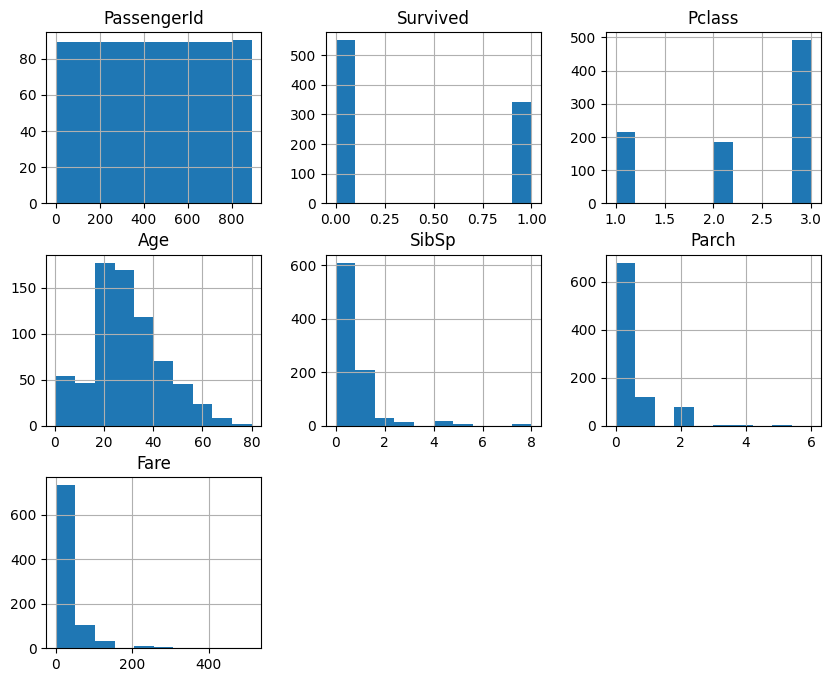

In [7]:
df.hist(figsize=(10,8))
plt.show()

# 2. Limpeza de Dados

**Observação do Professor:**
Nesta etapa de limpeza, eu comecei removendo as linhas duplicadas para evitar viés no modelo. Em seguida, realizei a imputação dos valores nulos: para a coluna `Age`, utilizei a mediana, que se mostra mais robusta contra valores extremos (outliers) do que a média; para `Embarked`, usei a moda (valor mais frequente). Por fim, removi a coluna `Cabin`, pois, como visto na exploração inicial, ela possui cerca de 77% de valores nulos, o que a torna inviável para o modelo neste cenário.

In [ ]:
df = df.drop_duplicates()

df['Age'] = df['Age'].fillna(df['Age'].median())                  # utilizei a mediana para substituir os valores nulos
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])  # utilizei a moda para substituir os valores nulos
df = df.drop(columns=['Cabin'])                                   # removi a coluna 'Cabin'

**Observação do Professor - Por que Moda e Mediana?**

O motivo de usarmos medidas estatísticas diferentes se deve à natureza dos dados (o tipo da variável) de cada coluna.

Em Ciência de Dados, a forma como tratamos os números é diferente da forma como tratamos categorias (textos). Vamos entender cada caso:

**1. Embarked (Porto de Embarque) = Variável Categórica**
A coluna Embarked contém texto, representando as categorias dos portos: 'S' (Southampton), 'C' (Cherbourg) e 'Q' (Queenstown).

- **Por que a Moda?** A moda representa o valor que mais se repete. Como não é possível calcular a média ou a mediana de letras/textos (não exite o valor "médio" entre 'S' e 'C'), a moda é a única medida de tendência central aplicável a dados categóricos.
- **A lógica:** Ao usar a moda, estamos basicamente dizendo: "Se não sabemos onde essa pessoa embarcou, vamos chutar que ela embarcou no porto de onde a esmagadora maioria das pessoas embarcou".

**2. Age (Idade) = Variável Numérica (Contínua)**
A coluna Age contém números (ex: 22.0, 38.0, 0.42). Para dados numéricos, a moda costuma ser uma escolha ruim, pois em variáveis contínuas os valores raramente se repetem o suficiente para que a moda represente de fato o "centro" dos dados. Sobram duas opções principais: a Média e a Mediana.

- **Por que a Mediana e não a Média?** A média é muito sensível a outliers (valores atípicos). Se tivermos muitos bebês no navio, ou alguns passageiros muito idosos (80 anos, como vimos no seu `describe()`), a média será "puxada" para cima ou para baixo, distorcendo a realidade. A mediana, por ser o valor exatamente do meio (quando os dados estão ordenados do menor para o maior), ignora os extremos e nos dá um retrato muito mais fiel da idade típica do passageiro do Titanic.

💡 **Resumo da Regra de Ouro na imputação de Nulos:**
- **Dados Numéricos (sem muitos outliers):** Média.
- **Dados Numéricos (com outliers ou distorcidos):** Mediana (geralmente a opção mais segura).
- **Dados Categóricos (Textos/Classes):** Moda.

# 3. Tratamento de Outliers

**Observação do Professor - Tratamento de Outliers (Método IQR):**

Como visualizamos lá em cima no histograma de `Fare` e nos dados numéricos da função `describe()`, a nossa Tarifa possuía alguns valores absurdamente altos em comparação à imensa maioria, criando o que chamamos de uma distribuição com cauda-longa à direita.

Para tratá-la matematicamente de forma correta sem ser por "chute", nós adotamos o consagrado Método **IQR (Intervalo Interquartil)**, a mesma matemática que rege os famosos gráficos de *Boxplot*.
- Primeiro, descobrimos quem dita os valores dos decisivos Quartil 1 (25%) e Quartil 3 (75%). 
- A diferença entre eles gera o Intervalo (o IQR).
- As "cercas" (bounds/limites aceitáveis) para excluir o que é bizarro são estipuladas com um limite máximo para cima e para baixo de `1.5 * IQR`.

Tudo que furar essa cerca (upper/lower), consideramos erro/outlier! E no código da próxima célula, com a linha `df = df[(df['Fare'] >= lower) & (df['Fare'] <= upper)]`, nós atualizamos o nosso banco de dados, excluindo estes ruídos mantendo apenas quem teve as finanças localizadas no miolo desta "cerca", que concentra cerca de 99,3% dos dados quando lidamos com distribuições normais.

![Tratamento de Outliers (IQR)](image/outliers.jpg)

In [ ]:
Q1 = df['Fare'].quantile(0.25) # calcula o primeiro quartil
Q3 = df['Fare'].quantile(0.75) # calcula o terceiro quartil

IQR = Q3 - Q1 

lower = Q1 - 1.5 * IQR # margem de tolerância
upper = Q3 + 1.5 * IQR # margem de tolerância

df = df[(df['Fare'] >= lower) & (df['Fare'] <= upper)]

# 4. Transformações Estatísticas

**Observação do Professor:**
Aqui nas transformações, eu apliquei inicialmente a transformação logarítmica (`np.log1p`) na coluna de tarifa (`Fare`). Fiz isso pois variáveis monetárias frequentemente apresentam uma forte assimetria à direita (uma cauda longa com valores extremos), e essa transformação ajuda a normalizar a distribuição dos dados.

**O "Poder Mágico" do Logaritmo:**
A função principal do logaritmo na estatística é ser um compressor de diferenças grandes. Ele encurta a distância física entre os números astronômicos, sem alterar a ordem das variáveis (quem for o mais rico continuará sendo o mais rico, porém a discrepância quantitativa será "espremida").

Exemplo prático de compressão: (Lembrete numérico na base 10, apenas para fins lúdicos de sala de aula, enquanto o NumPy utiliza base logaritmo natural por baixo dos panos)

Caso tivéssemos 3 passageiros pagando: 10 ... 100 ... e 1000.

Distância sem usar Log: Entre 10 e 1000 a distância pura num gráfico é enorme! (1000 - 10 = diferença de 990).
A mágica do Log: log10(10) = 1 | log10(100) = 2 | log10(1000) = 3
Conclusão: Após o Log, os exatos mesmos valores se transformaram numa nova coluna onde valem na escala da máquina: 1 ... 2 ... e 3.
Pronto! Nós pegamos uma série de preços com um pico astronômico e a forçamos a assumir o desenho de um comportamento mais suave, próximo de uma distribuição da curva de sino. E aí sim o aprendizado de máquina funciona da melhor forma!

In [ ]:
df['Fare_log'] = np.log1p(df['Fare'])

**Observação do Professor:**

Logo após, com o auxílio do `StandardScaler`, eu padronizei as features contínuas. Colocá-las na mesma escala (com média 0 e desvio padrão 1) é fundamental para garantir a performance e a convergência de muitos algoritmos de Machine Learning.

In [9]:
scaler = StandardScaler()
df[['Age','Fare_log']] = scaler.fit_transform(df[['Age','Fare_log']])

# 5. Encoding

**Observação do Professor:**
Nesta célula, eu utilizei a técnica de One-Hot Encoding por meio da função `pd.get_dummies`. Observem o uso do parâmetro `drop_first=True`. Eu o implementei como uma boa prática para evitar a chamada 'armadilha da variável dummy' (quando há multicolinearidade perfeita entre os atributos criados), prevenindo impactos negativos, especialmente em modelos descritivos e lineares.

In [ ]:
df = pd.get_dummies(df, columns=['Sex','Embarked'], drop_first=True)

# 6. Seleção de Features

**Observação do Professor:**
Atenção para um detalhe metodológico muito importante! O uso da função `chi2` (Qui-Quadrado) para a seleção de atributos **exige que os dados de entrada sejam restritamente não-negativos**. Como eu padronizei os dados com o `StandardScaler` na etapa anterior, valores negativos foram introduzidos em nosso conjunto.

Poderíamos ser tentados a mascarar esse cenário usando o valor absoluto (`abs(X)`), no entanto, fazer isso em dados padronizados destrói o seu significado estatístico (ex: uma característica que esteja 2 desvios-padrão abaixo da média seria tratada identicamente a uma que estivesse 2 acima). Para corrigir isto, substituí a métrica para a Análise de Variância (`f_classif`), que lida corretamente com variáveis contínuas padronizadas em problemas de classificação.

In [11]:
X = df.drop(columns=['Survived','Name','Ticket','PassengerId','Fare'])
y = df['Survived']

In [ ]:
from sklearn.feature_selection import f_classif

selector = SelectKBest(score_func=f_classif, k=5)
X_new = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]
selected_features

# 7. Split do Dataset

**Observação do Professor - Prevenção ao Vazamento de Dados (Data Leakage):**

Chegamos à separação do dataset! Faço este alerta agora para ressaltar a seguinte escolha que inseri neste material didático: realizamos imputações (mediana/moda), tratamento de outliers e padronização ANTES de invocar o `train_test_split`. 

Atenção redobrada na prática: os dados de teste sempre representam eventos futuros. Se eu calcular uma métrica global para imputação agrupando o dataset inteiro, estarei vazando informações do teste para o treino do modelo, tornando-o ingenuamente otimista. Em desafios mais avançados em nosso curso, aplicaremos os `Pipelines` do `scikit-learn` para blindar completamente o modelo desses riscos!

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X[selected_features], y, test_size=0.2, random_state=42
)

NameError: name 'selected_features' is not defined

# Balanceamento com SMOTE

In [ ]:
smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(X_train.shape)
print(X_train_balanced.shape)